In [93]:
import numpy as np
import math
from scipy.stats import norm
from scipy.integrate import quad

## Background: FX Forwards & Swaps

In [71]:
class FXForwardPricer:
    def __init__(self, spot_rate: float, r_base: float, r_quote: float, days_to_maturity: int, fx_volatility: float, days_in_year: int = 360):
        """
        Initializes the FX Forward Pricer using continuous compounding.
        
        :param spot_rate: Current spot exchange rate (Quote currency per 1 unit of Base currency)
        :param r_base: Interest rate of the base currency (decimal)
        :param r_quote: Interest rate of the quote currency (decimal)
        :param days_to_maturity: Number of days until contract settlement
        :param days_in_year: Day count convention (typically 360 or 365)
        """
        self.S = spot_rate
        self.r_b = r_base
        self.r_q = r_quote
        self.T = days_to_maturity / days_in_year
        self.vol = fx_volatility

    def calculate_forward_rate(self):
        """Calculates the theoretical forward rate using Covered Interest Rate Parity."""
        # Formula: F = S * e^((r_q - r_b) * T)
        forward_rate = self.S * math.exp((self.r_q - self.r_b) * self.T)
        return forward_rate

    def calculate_forward_points(self):
        """Calculates forward points (typically scaled by 10,000 for pips)."""
        F = self.calculate_forward_rate()
        return (F - self.S) * 10000

    def mark_to_market(self, contracted_rate: float, position: str = "buy"):
        """
        Calculates the present value (PV) of an open forward position per unit of base currency.
        
        :param contracted_rate: The forward rate locked in at the start of the contract
        :param position: 'buy' if buying base/selling quote, 'sell' if selling base/buying quote
        """
        F = self.calculate_forward_rate()
        
        if position.lower() == "buy":
            payoff = F - contracted_rate
        elif position.lower() == "sell":
            payoff = contracted_rate - F
        else:
            raise ValueError("Position must be 'buy' or 'sell'")
            
        # Discount the payoff using the quote currency interest rate
        pv = payoff * math.exp(-self.r_q * self.T)
        return pv
        
        ## Calculating CVA adjustments
    def calculate_epe(self, contracted_rate: float, position: str = "buy"):
        """
        Approximates Expected Positive Exposure (EPE) using a Black-Scholes analytic approximation
        for the positive tail distribution of the forward contract value at maturity.
        """
        F = self.calculate_forward_rate()
        
        # Avoid division by zero for instant maturity
        if self.T <= 0 or self.vol <= 0:
            return max(0.0, self.calculate_risk_free_pv(contracted_rate, position))
            
        d1 = (math.log(F / contracted_rate) + (0.5 * self.vol**2) * self.T) / (self.vol * math.sqrt(self.T))
        d2 = d1 - self.vol * math.sqrt(self.T)
        
        if position.lower() == "buy":
            # Call-option-like structure for exposure
            epe_at_maturity = F * norm.cdf(d1) - contracted_rate * norm.cdf(d2)
        else:
            # Put-option-like structure for exposure
            epe_at_maturity = contracted_rate * norm.cdf(-d2) - F * norm.cdf(-d1)
            
        # Discount back to present value using quote currency rate
        return epe_at_maturity * math.exp(-self.r_q * self.T)

    def calculate_cva(self, contracted_rate: float, pd: float, lgd: float, position: str = "buy"):
        """
        Calculates Credit Valuation Adjustment (CVA).
        Formula: CVA = EPE * PD * LGD
        """
        # Ensure position is asset-side for counterparty risk tracking
        epe = self.calculate_epe(contracted_rate, position)
        cva = epe * pd * lgd
        return cva
        
    def price_credit_adjusted_forward(self, contracted_rate: float, pd: float, lgd: float, position: str = "buy"):
        """Returns full breakdown of risk-free and credit-adjusted metrics."""
        rf_pv = self.mark_to_market(contracted_rate, position)
        cva = self.calculate_cva(contracted_rate, pd, lgd, position)
        
        credit_adjusted_pv = rf_pv - cva
        
        return {
            "Proxy CVA": cva,
        }
        
    def generate_swap_schedule(self, base_notional: float, direction: str = "buy_sell"):
        """
        Generates cash flows for both legs of the FX Swap.
        
        :param base_notional: Amount of the base currency being traded
        :param direction: 'buy_sell' (Buy Base Spot / Sell Base Forward) 
                          or 'sell_buy' (Sell Base Spot / Buy Base Forward)
        """
        F = self.calculate_forward_rate()
        quote_notional_near = base_notional * self.S
        quote_notional_far = base_notional * F
        
        if direction.lower() == "buy_sell":
            # Near Leg: Receive Base, Pay Quote
            near_base, near_quote = base_notional, -quote_notional_near
            # Far Leg: Pay Base, Receive Quote
            far_base, far_quote = -base_notional, quote_notional_far
        elif direction.lower() == "sell_buy":
            # Near Leg: Pay Base, Receive Quote
            near_base, near_quote = -base_notional, quote_notional_near
            # Far Leg: Receive Base, Pay Quote
            far_base, far_quote = base_notional, -quote_notional_far
        else:
            raise ValueError("Direction must be 'buy_sell' or 'sell_buy'")

        return {
            "Spot Rate (Near Leg)": self.S,
            "Forward Rate (Far Leg)": F,
            "Swap Points (Pips)": self.calculate_forward_points(),
            "Near Leg Cash Flows": {f"Base": near_base, f"Quote": near_quote},
            "Far Leg Cash Flows": {f"Base": far_base, f"Quote": far_quote}
        }


1. https://uk.finance.yahoo.com/quote/USDKES=X/
2. https://tradingeconomics.com/kenya/interest-rate
3. https://www.global-rates.com/en/interest-rates/sofr/


In [79]:
if __name__ == "__main__":
    spot = 129.75
    r_usd = 0.0351  # Base currency rate (4.5%)
    r_kes = 0.0875  # Quote currency rate (8.75%)
    days = 180
    fx_volatility = 0.12  # 12% annualized FX volatility
    counterparty_pd = 0.03   # 3% Default Probability over the term
    counterparty_lgd = 0.60  # 60% Loss Given Default (40% Recovery Rate)
    
    pricer = FXForwardPricer(spot_rate = spot, r_base = r_usd, r_quote = r_kes, days_to_maturity = days, fx_volatility = fx_volatility)
    
    fwd_rate = pricer.calculate_forward_rate()
    fwd_points = pricer.calculate_forward_points()
    
    # Assume we previously locked in a buy contract at 132.10
    old_contract_rate = 132.10
    mtm_val = pricer.mark_to_market(contracted_rate = old_contract_rate, position="buy")
    results = pricer.price_credit_adjusted_forward(contracted_rate = old_contract_rate, pd = counterparty_pd,lgd = counterparty_lgd,position = "buy")
    trade_summary = pricer.generate_swap_schedule(base_notional=10000000, direction="buy_sell")
    
    print(f"--- FX Forward Pricing Results ---")
    print(f"Spot Rate:         {spot:.4f}")
    print(f"Forward Rate:      {fwd_rate:.4f}")
    print(f"Forward Points:    {fwd_points:.1f} pips")
    print(f"MTM PV Value:      {mtm_val:.4f} per unit of base currency")
    for key, value in results.items():
        print(f"{key:<20}: {value:.6f}")
        
    print("=== FX SWAP PRICING SUMMARY ===")
    print(f"Spot Rate:         {trade_summary['Spot Rate (Near Leg)']:,.4f}")
    print(f"Forward Rate:      {trade_summary['Forward Rate (Far Leg)']:,.4f}")
    print(f"Swap Points:       {trade_summary['Swap Points (Pips)']:,.1f} pips\n")
    
    print("=== CASH FLOWS ===")
    print(f"Near Leg (T+2):    KES {trade_summary['Near Leg Cash Flows']['Base']:+,} | USD {trade_summary['Near Leg Cash Flows']['Quote']:+,}")
    print(f"Far Leg (T+180):   KES {trade_summary['Far Leg Cash Flows']['Base']:+,} | USD {trade_summary['Far Leg Cash Flows']['Quote']:+,}")

--- FX Forward Pricing Results ---
Spot Rate:         129.7500
Forward Rate:      133.1944
Forward Points:    34443.7 pips
MTM PV Value:      1.0475 per unit of base currency
Proxy CVA           : 0.087135
=== FX SWAP PRICING SUMMARY ===
Spot Rate:         129.7500
Forward Rate:      133.1944
Swap Points:       34,443.7 pips

=== CASH FLOWS ===
Near Leg (T+2):    KES +10,000,000 | USD -1,297,500,000.0
Far Leg (T+180):   KES -10,000,000 | USD +1,331,943,742.7557433


## FX Options: (a) Garman-Kohlhagen Model

An extension of the Black-Scholes model, this is specifically used to price foreign exchange options, taking into account both the volatility and interest rates of the two currencies involved.

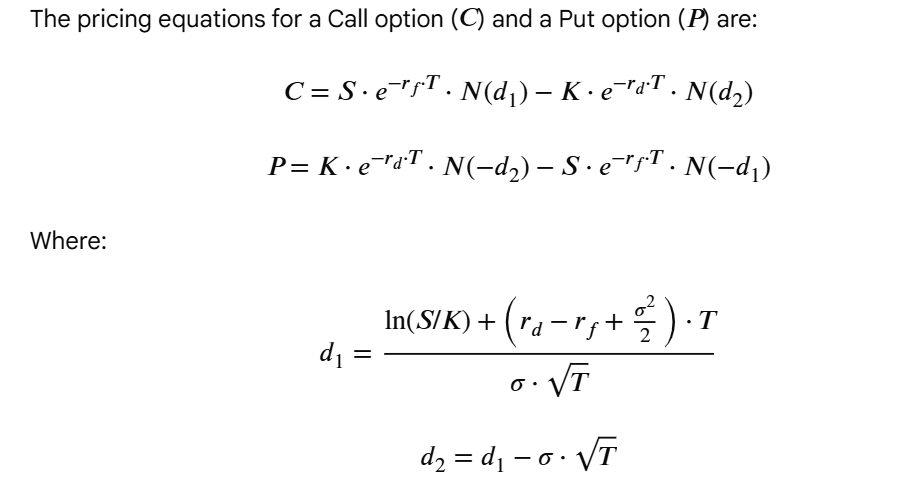

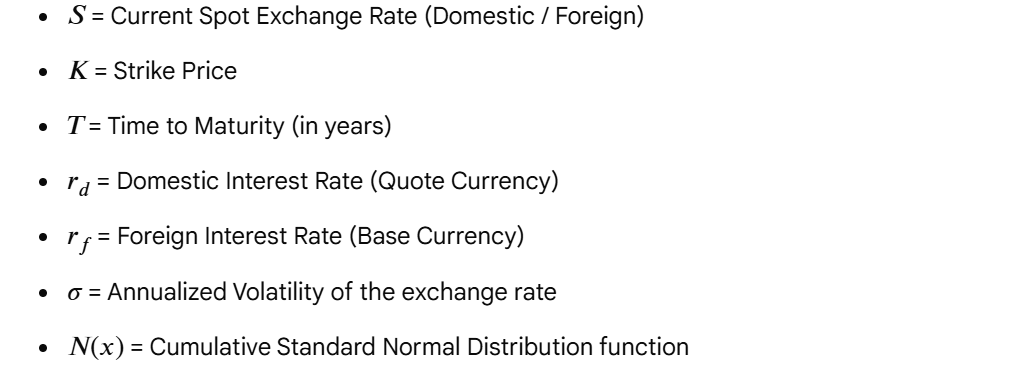

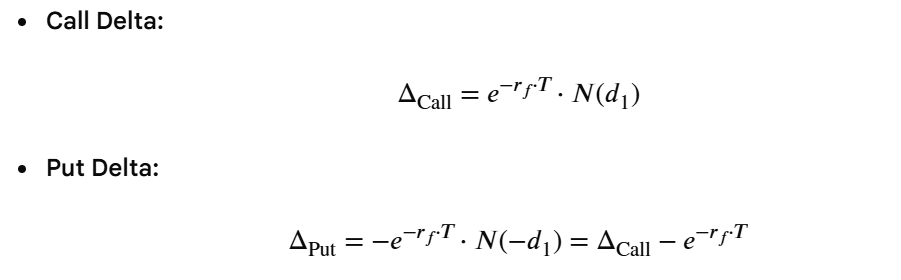

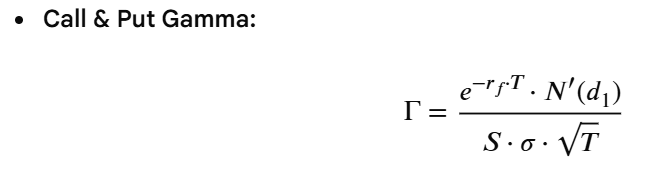

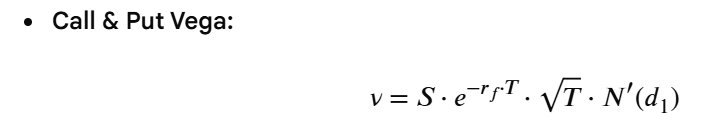

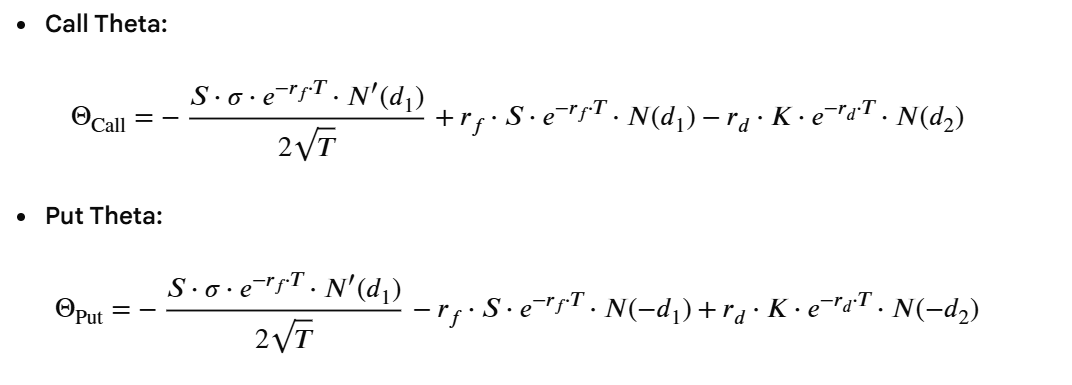

In [85]:
class GarmanKohlhagenPricer:
    def __init__(self, spot_rate: float, strike: float, time_to_expiry: float, r_domestic: float, r_foreign: float, volatility: float):
        """
        Initializes the Garman-Kohlhagen FX Option Pricing Model.
        
        :param spot_rate: Current spot exchange rate (Domestic currency per 1 Foreign unit)
        :param strike: Option strike price
        :param time_to_expiry: Time to expiration in years (e.g., 0.5 for 6 months)
        :param r_domestic: Risk-free rate of the domestic/quote currency (decimal)
        :param r_foreign: Risk-free rate of the foreign/base currency (decimal)
        :param volatility: Annualized volatility of the FX spot rate (decimal)
        """
        self.S = spot_rate
        self.K = strike
        self.T = time_to_expiry
        self.rd = r_domestic
        self.rf = r_foreign
        self.vol = volatility
        
        # Pre-calculate d1 and d2 to reuse across pricing and Greeks
        self._calculate_d1_d2()

    def _calculate_d1_d2(self):
        """Internal helper to calculate d1 and d2 components."""
        if self.T <= 0 or self.vol <= 0:
            self.d1, self.d2 = 0.0, 0.0
            return
            
        numerator_d1 = math.log(self.S / self.K) + (self.rd - self.rf + 0.5 * self.vol**2) * self.T
        denominator = self.vol * math.sqrt(self.T)
        
        self.d1 = numerator_d1 / denominator
        self.d2 = self.d1 - denominator

    def price(self, option_type: str = "call"):
        """Calculates the analytical premium of the FX option."""
        if option_type.lower() == "call":
            return (self.S * math.exp(-self.rf * self.T) * norm.cdf(self.d1) - self.K * math.exp(-self.rd * self.T) * norm.cdf(self.d2))
        elif option_type.lower() == "put":
            return (self.K * math.exp(-self.rd * self.T) * norm.cdf(-self.d2) - self.S * math.exp(-self.rf * self.T) * norm.cdf(-self.d1))
        else:
            raise ValueError("Option type must be 'call' or 'put'")

    def greeks(self, option_type: str = "call"):
        """Calculates the standard market risk sensitivities (Greeks)."""
        sqrt_T = math.sqrt(self.T)
        nd1_prime = norm.pdf(self.d1) # Probability density function for gamma/vega
        
        # Delta
        if option_type.lower() == "call":
            delta = math.exp(-self.rf * self.T) * norm.cdf(self.d1)
        else:
            delta = -math.exp(-self.rf * self.T) * norm.cdf(-self.d1)
            
        # Gamma (same for Call and Put)
        gamma = (math.exp(-self.rf * self.T) * nd1_prime) / (self.S * self.vol * sqrt_T)
        
        # Vega (same for Call and Put, divided by 100 to show impact per 1% change in vol)
        vega = (self.S * math.exp(-self.rf * self.T) * sqrt_T * nd1_prime) / 100
        
        # Theta (annualized decay divided by 365 to show daily impact)
        term1 = -(self.S * self.vol * math.exp(-self.rf * self.T) * nd1_prime) / (2 * sqrt_T)
        if option_type.lower() == "call":
            term2 = self.rf * self.S * math.exp(-self.rf * self.T) * norm.cdf(self.d1)
            term3 = self.rd * self.K * math.exp(-self.rd * self.T) * norm.cdf(self.d2)
            theta = (term1 + term2 - term3) / 365
        else:
            term2 = self.rf * self.S * math.exp(-self.rf * self.T) * norm.cdf(-self.d1)
            term3 = self.rd * self.K * math.exp(-self.rd * self.T) * norm.cdf(-self.d2)
            theta = (term1 - term2 + term3) / 365

        return {"Delta": delta, "Gamma": gamma, "Vega": vega, "Theta (Daily)": theta}


In [107]:
if __name__ == "__main__":
    spot = 129.75
    r_usd = 0.0351  # Base currency rate (4.5%)
    r_kes = 0.0875  # Quote currency rate (8.75%)
    strike = 132.10
    days = 0.5
    fx_volatility = 0.12  # 12% annualized FX volatility    
    pricer = GarmanKohlhagenPricer(spot_rate = spot, strike = strike, time_to_expiry = days, r_domestic = r_usd, r_foreign = r_kes, 
                                   volatility = fx_volatility)
    
    for op_type in ["call", "put"]:
        opt_price = pricer.price(option_type=op_type)
        opt_greeks = pricer.greeks(option_type=op_type)
        
        print(f"=== {op_type.upper()} OPTION PRICING RESULTS ===")
        print(f"Premium/Price : {opt_price:.5f}")
        for greek, val in opt_greeks.items():
            print(f"{greek:<14}: {val:.5f}")
        print("-" * 30)

=== CALL OPTION PRICING RESULTS ===
Premium/Price : 2.06329
Delta         : 0.30282
Gamma         : 0.03094
Vega          : 0.31254
Theta (Daily) : -0.00444
------------------------------
=== PUT OPTION PRICING RESULTS ===
Premium/Price : 7.66934
Delta         : -0.65437
Gamma         : 0.03094
Vega          : 0.31254
Theta (Daily) : -0.02173
------------------------------


## FX Options: (b) Binomial Model

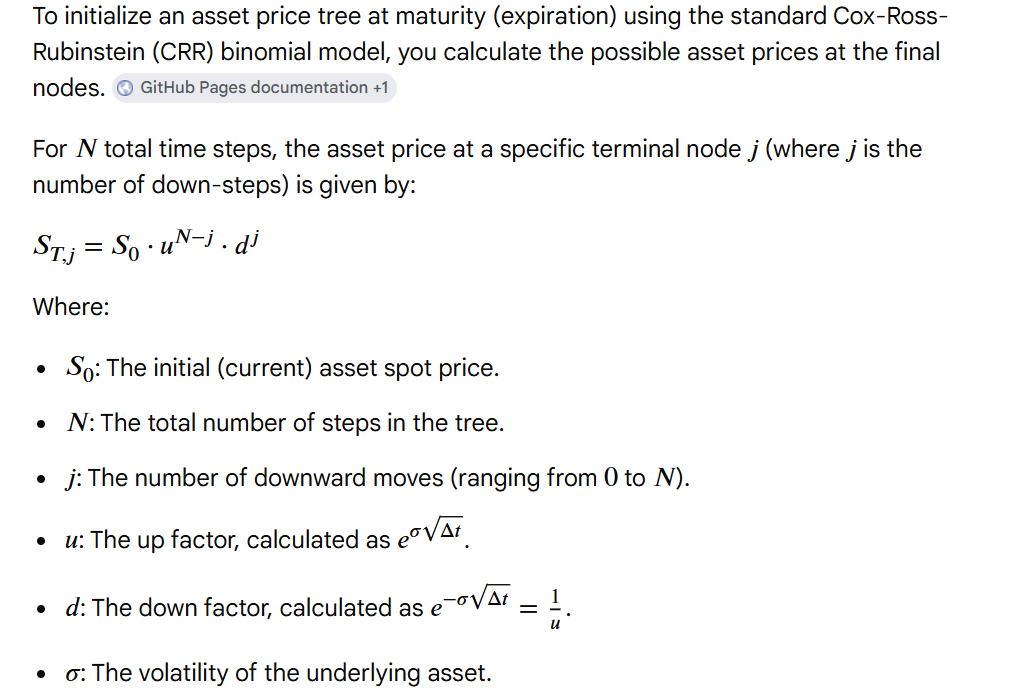

In [5]:
def binomial_fx_option(S, K, T, r_dom, r_for, sigma, N, option_type='call'):
    """
    Prices a European Currency Option using the Binomial (Cox-Ross-Rubinstein) model.
    
    Parameters:
    S (float) : Spot FX rate (domestic per unit of foreign currency)
    K (float) : Strike price
    T (float) : Time to maturity in years
    r_dom (float): Domestic risk-free interest rate
    r_for (float): Foreign risk-free interest rate
    sigma (float): Volatility of the exchange rate
    N (int)   : Number of binomial steps
    option_type (str): 'call' or 'put'
    """
    dt = T / N
    u = np.exp(sigma * np.sqrt(dt)) # up-factor in binomial models
    d = 1 / u # ensure recombining tree
    
    # Risk-neutral probability incorporating foreign rate
    p = (np.exp((r_dom - r_for) * dt) - d) / (u - d)
    
    # Initialize asset price tree at maturity
    # Ex: S_T = S * u^j * d^(N-j)
    j = np.arange(N + 1)
    st = S * (u ** j) * (d ** (N - j))
    
    # Initialize option payoffs at maturity
    if option_type == 'call':
        option_values = np.maximum(0, st - K)
    elif option_type == 'put':
        option_values = np.maximum(0, K - st)
    else:
        raise ValueError("option_type must be 'call' or 'put'")

    # Backward induction (discounting and probability weighting)
    discount_factor = np.exp(-r_dom * dt)
    for i in range(N - 1, -1, -1):
        option_values = discount_factor * (p * option_values[1:] + (1 - p) * option_values[:-1])
        
    return option_values[0]

In [105]:
# Example usage:
S = 129.75       
K = 132.10     # Strike
T = 0.5        # 6 months
r_dom = 0.0351   # US risk-free rate 
r_for = 0.0875   # Kenya risk-free rate 
sigma = 0.12   # Volatility (12%)
N = 100        # 100 steps

call_price = binomial_fx_option(S, K, T, r_dom, r_for, sigma, N, 'call')
put_price = binomial_fx_option(S, K, T, r_dom, r_for, sigma, N, 'put')
print(f"FX Call Option Price: {call_price:.4f}")
print(f"FX Put Option Price: {put_price:.4f}")

FX Call Option Price: 2.0572
FX Put Option Price: 7.6633


## FX Options: (c) Heston Model

A more advanced stochastic volatility model that assumes the volatility of the asset follows a mean-reverting process. It is particularly useful for pricing options in markets where volatility is unpredictable. The Heston model allows volatility to vary over time and exhibit mean-reversion, which naturally captures the real-world FX volatility smile.

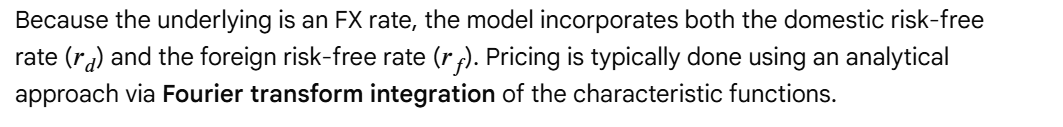

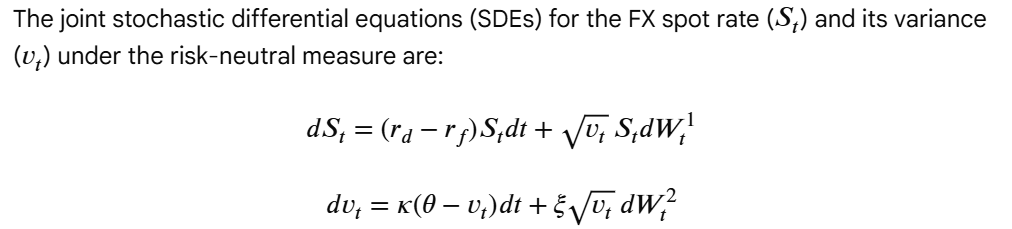

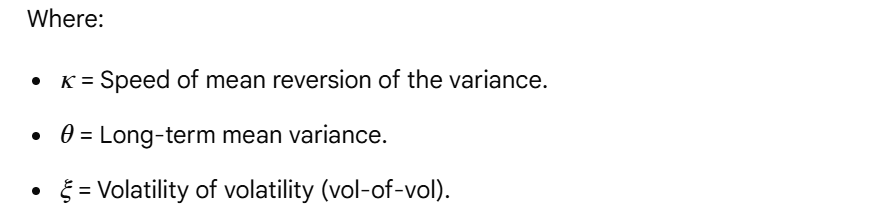

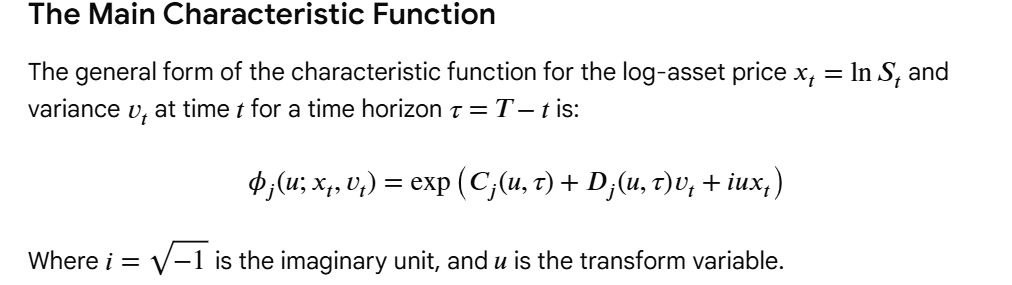
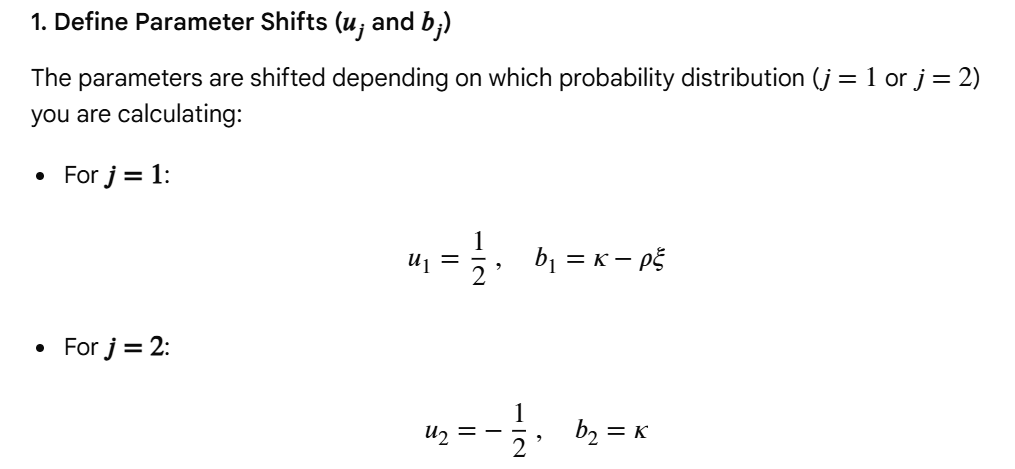
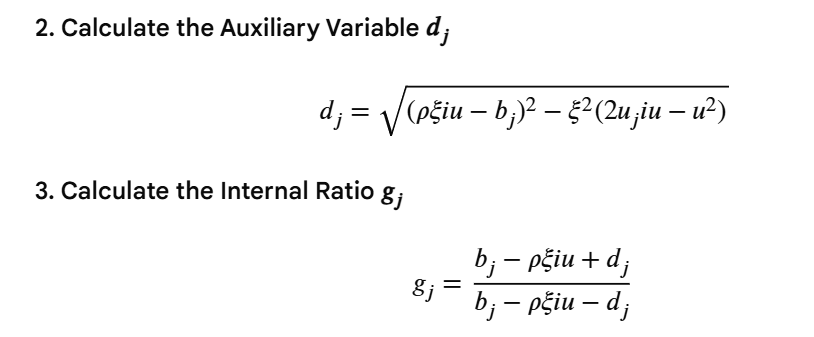
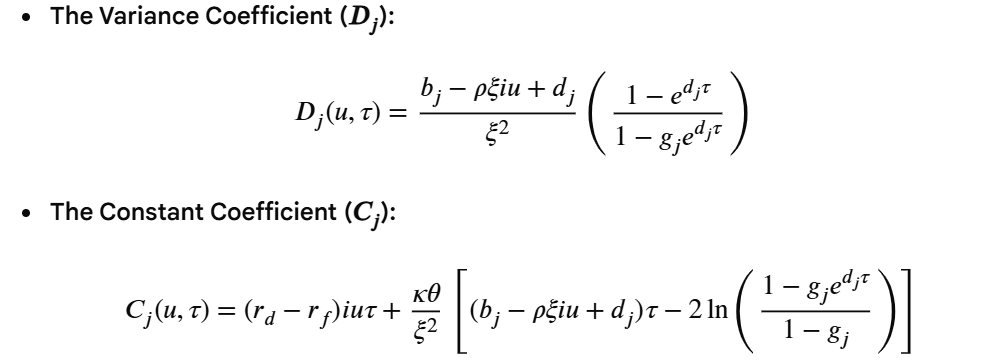

To convert the characteristic functions back into true risk-neutral probability distributions (P1 and P2), we apply Gil-Pelaez inversion integrals.The mathematical formulation for the Integrand function (Ij) required inside the numerical integration step is:

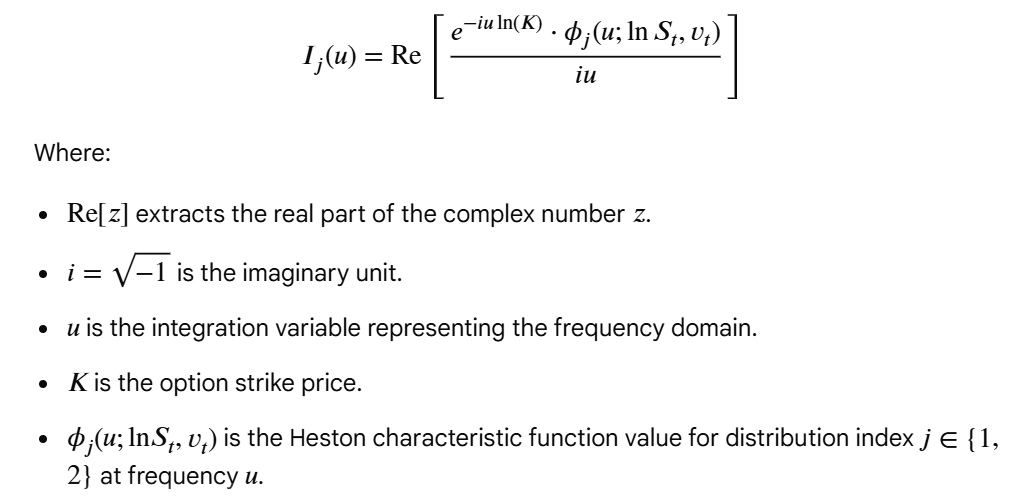
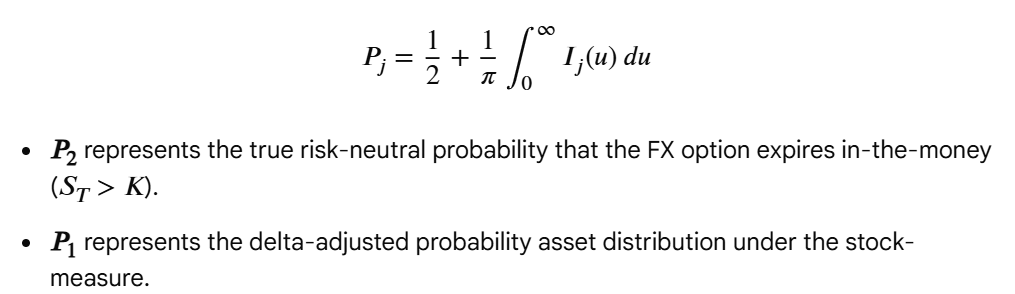
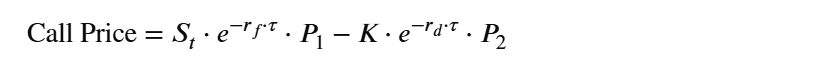
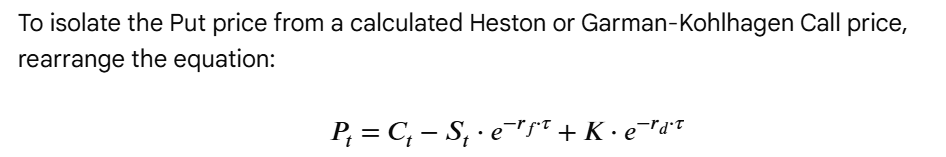

In [97]:
class HestonFXPricer:
    def __init__(self, spot: float, strike: float, expiry: float, r_domestic: float, r_foreign: float,
                 v0: float, kappa: float, theta: float, xi: float, rho: float):
        """
        Initializes the Heston Stochastic Volatility engine for FX options.
        
        :param spot: Current spot FX rate (Domestic/Foreign)
        :param strike: Option strike price
        :param expiry: Time to maturity in years (T)
        :param r_domestic: Risk-free rate of the domestic/quote currency (r_d)
        :param r_foreign: Risk-free rate of the foreign/base currency (r_f)
        :param v0: Initial variance (current volatility squared)
        :param kappa: Speed of mean reversion of variance
        :param theta: Long-term mean variance
        :param xi: Volatility of volatility (vol-of-vol)
        :param rho: Correlation between spot and variance assets
        """
        self.S = spot
        self.K = strike
        self.T = expiry
        self.rd = r_domestic
        self.rf = r_foreign
        self.v0 = v0
        self.kappa = kappa
        self.theta = theta
        self.xi = xi
        self.rho = rho

    def _characteristic_function(self, u, type_index):
        """Computes the Heston characteristic function components."""
        # Mapping type index to Heston parameter shifts
        if type_index == 1:
            u_adj = 0.5
            b = self.kappa - self.rho * self.xi
        else:
            u_adj = -0.5
            b = self.kappa

        # Compute d and g components
        # Note: 'u' is treated as a complex number vector component (u * 1j)
        comp_u = u * 1j
        d = np.sqrt((self.rho * self.xi * comp_u - b)**2 - self.xi**2 * (2 * u_adj * comp_u - u**2))
        g = (b - self.rho * self.xi * comp_u + d) / (b - self.rho * self.xi * comp_u - d)
        
        # Characteristic function exponential terms
        C = ((self.rd - self.rf) * comp_u * self.T + (self.kappa * self.theta / self.xi**2) * 
             ((b - self.rho * self.xi * comp_u + d) * self.T - 2 * np.log((1 - g * np.exp(d * self.T)) / (1 - g))))
        D = ((b - self.rho * self.xi * comp_u + d) / self.xi**2) * ((1 - np.exp(d * self.T)) / (1 - g * np.exp(d * self.T)))
        return np.exp(C + D * self.v0 + comp_u * np.log(self.S))

    def _probability_integrand(self, u, type_index):
        """Integrand function required for the numerical integration step."""
        phi = self._characteristic_function(u, type_index)
        integrand = np.real(np.exp(-u * 1j * np.log(self.K)) * phi / (u * 1j))
        return integrand

    def _calculate_probabilities(self):
        """Numerically integrates the standard probability distributions P1 and P2."""
        # Scipy quad handles real numerical integration safely up to limit boundaries
        p1_integral, _ = quad(self._probability_integrand, 0, 100, args=(1,))
        p2_integral, _ = quad(self._probability_integrand, 0, 100, args=(2,))
        
        P1 = 0.5 + (1 / np.pi) * p1_integral
        P2 = 0.5 + (1 / np.pi) * p2_integral
        return P1, P2

    def price(self, option_type: str = "call") -> float:
        """Calculates the Heston analytical premium for Call or Put options."""
        P1, P2 = self._calculate_probabilities()
        
        call_price = (self.S * np.exp(-self.rf * self.T) * P1 - self.K * np.exp(-self.rd * self.T) * P2)
        
        if option_type.lower() == "call":
            return max(0.0, call_price)
        elif option_type.lower() == "put":
            # Extract Put price via Put-Call Parity modified for foreign yields
            put_price = call_price - self.S * np.exp(-self.rf * self.T) + self.K * np.exp(-self.rd * self.T)
            return max(0.0, put_price)
        else:
            raise ValueError("Option type must be 'call' or 'put'")


In [103]:
if __name__ == "__main__":
    spot = 129.75
    r_usd = 0.0351  # Base currency rate (4.5%)
    r_kes = 0.0875  # Quote currency rate (8.75%)
    strike = 132.10
    days = 0.5      # 6 months
    
    # Heston Model specific volatility parameters
    initial_variance = 0.01   # Corresponds to a baseline vol sqrt(0.01) = 10%
    mean_reversion = 2.0      # Kappa: speed of adjustment
    long_term_var = 0.0144    # Theta: long term variance target (sqrt(0.0144) = 12% vol)
    vol_of_vol = 0.25        # Xi: volatility of variance asset
    correlation = -0.40       # Rho: directional skew indicator
    
    pricer = HestonFXPricer(spot = spot, strike = strike, expiry = days, r_domestic = r_usd, r_foreign = r_kes, v0 = initial_variance,
        kappa = mean_reversion, theta = long_term_var, xi = vol_of_vol, rho = correlation)
    
    call_premium = pricer.price("call")
    put_premium = pricer.price("put")
    
    print("=== HESTON STOCHASTIC VOLATILITY FX OPTION RESULTS ===")
    print(f"Heston Call Premium: {call_premium:.5f}")
    print(f"Heston Put Premium : {put_premium:.5f}")

=== HESTON STOCHASTIC VOLATILITY FX OPTION RESULTS ===
Heston Call Premium: 1.35485
Heston Put Premium : 6.96090
